# Agentic RAG using LangGraph, Ollama-Gemma, and Qdrant.

## Overview

- Part-1: Load Ollama Model on Colab
- Part-2: Document Processing
- Part-3: Agentic RAG using Routing Function calling

## Installation

In [2]:
!pip install langgraph langchain-community pypdfium2
!pip install langchain-qdrant fastembed
!pip install langchain-ollama # llm : gemma-3n
!pip install duckduckgo-search ddgs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 119.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

## Part-1: Inference Ollama on Colab

In [3]:
!apt-get install -y zstd curl
!curl -fsSL https://ollama.com/install.sh | sh

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
curl is already the newest version (7.81.0-1ubuntu1.21).
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 37 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 1s (425 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> A

In [4]:
import subprocess
import time

proc = subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
# I want ollama serve command to be always active until I am using Colab
time.sleep(3) # localhost (colab server)

# Ollama
# If you have GPU: vLLM and SGLang (https://github.com/sgl-project/sglang)

In [5]:
model_name = "gemma3n:e4b"
# open source:
# gemma, kimi, qwen and glm
# mistral

In [6]:
import ollama
ollama.pull(model_name) # this step will take around ~2 minutes to load the model depending on the GPU kernel

ProgressResponse(status='success', completed=None, total=None, digest=None)

In [7]:
ollama.pull("gemma3:12b-cloud")

ProgressResponse(status='success', completed=None, total=None, digest=None)

### Testing of the model

In [8]:
response = ollama.chat(
    model=model_name,
    messages=[
    {
      'role': 'user',
      'content': 'what is soo special about Malaysia?',
    },
])

In [9]:
print(response['message']['content'])

Malaysia is a truly fascinating country with a lot to offer! Here's a breakdown of what makes it so special, covering a wide range of aspects:

**1. Cultural Melting Pot:**

*   **Diversity:** This is arguably Malaysia's biggest draw. It's a vibrant mix of Malay, Chinese, Indian, and indigenous cultures. This creates a unique blend of traditions, languages, religions, and cuisines.
*   **Festivals:**  You'll find a calendar packed with festivals reflecting this diversity – Hari Raya Aidilfitri (Malay), Chinese New Year, Deepavali (Hindu), and many more.  These festivals are celebrated with incredible energy and enthusiasm.
*   **Multilingualism:**  While Bahasa Malaysia is the national language, English is widely spoken, especially in business and tourism.  You'll also hear various regional languages.
*   **Harmony:** Despite the cultural differences, Malaysia has a long history of relative peace and harmony between its diverse communities.  It's a testament to a shared national identi

In [11]:
import os
from google.colab import userdata

os.environ['OLLAMA_API_KEY']= userdata.get("OLLAMA_API_KEY")

In [12]:
from ollama import Client

client = Client(
    host="https://ollama.com",
    headers={'Authorization': 'Bearer ' + os.environ.get('OLLAMA_API_KEY')}
)

In [13]:
messages=[
    {
      'role': 'user',
      'content': 'top 10 beautiful cities in Asia',
    },
]

In [14]:
response = client.chat(
    model="gemma3:12b",
    messages=messages,
)

In [15]:
print(response['message']['content'])

Okay, compiling a "top 10" list is *always* subjective, and "beautiful" means different things to different people! This list considers a mix of stunning natural landscapes, impressive architecture, vibrant culture, and overall aesthetic appeal. I've tried to offer a diverse range of cities.  Here's my take on 10 beautiful cities in Asia, with a little about what makes them special.  **Please read the notes at the bottom about caveats and alternatives!**

1.  **Kyoto, Japan:** (Classic Beauty & Tradition)
    *   **Why it's beautiful:**  Kyoto is the heart of traditional Japan.  Think meticulously manicured gardens, serene temples (like Kinkaku-ji – the Golden Pavilion), graceful geishas in Gion, bamboo forests (Arashiyama), and exquisite craftsmanship. It's a city that feels like stepping back in time, but with modern comforts. The seasonal changes (cherry blossoms in spring, vibrant foliage in autumn) add layers of beauty.
    *   **Key Features:** Temples, Gardens, Traditional Archi

## Part-2: Document processing

In [16]:
# pdf
from langchain_community.document_loaders import PyPDFium2Loader # https://arxiv.org/pdf/2410.09871
from langchain_text_splitters import RecursiveCharacterTextSplitter

# embedding model
from langchain_community.embeddings import FastEmbedEmbeddings # sparse (keyword search) and dense (vector) (hybrid search)

# vector database dependency
from langchain_qdrant import FastEmbedSparse, QdrantVectorStore, RetrievalMode # hybrid
from qdrant_client import QdrantClient, models

### Data loading- Raw data extraction

In [17]:
!wget https://data.imf.org/-/media/iData/External-Storage/Documents/7FC05452C6C743D2BFB6188D2E248A38/en/2025-FAS-Annual-Report.pdf -O annual_report.pdf

--2026-03-12 07:55:06--  https://data.imf.org/-/media/iData/External-Storage/Documents/7FC05452C6C743D2BFB6188D2E248A38/en/2025-FAS-Annual-Report.pdf
Resolving data.imf.org (data.imf.org)... 23.211.108.58, 23.211.108.73, 2600:1406:5e00:9f::17d2:d89b, ...
Connecting to data.imf.org (data.imf.org)|23.211.108.58|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1979418 (1.9M) [application/pdf]
Saving to: ‘annual_report.pdf’

annual_report.pdf   100%[===================>]   1.89M  --.-KB/s    in 0.04s   

2026-03-12 07:55:08 (45.7 MB/s) - ‘annual_report.pdf’ saved [1979418/1979418]



In [18]:
path = "annual_report.pdf"
loader = PyPDFium2Loader(path)

In [19]:
docs = loader.load() # extract the raw data: page_content and metadata objects (Langchain document)

In [20]:
len(docs)

31

In [21]:
docs[20].metadata

{'producer': 'iLovePDF',
 'creator': '',
 'creationdate': '',
 'title': '',
 'author': '',
 'subject': '',
 'keywords': '',
 'moddate': '2025-10-11T02:18:25+00:00',
 'source': 'annual_report.pdf',
 'total_pages': 31,
 'page': 20}

In [22]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1536, # 1024
    chunk_overlap = 0,
)
chunks = text_splitter.split_documents(docs)

In [24]:
len(chunks)

66

In [25]:
chunks[2].page_content

'FINTECH, A CATALYST FOR FINANCIAL SERVICES ACCESS, INNOVATION, AND GROWTH\n1\nContents\nExecutive Summary .............................................................................................................................................. 2\nAcronyms and Abbreviations .............................................................................................................................. 3\n1. The Macro-Critical Role of Financial Access and Use: Insights and Recent Developments.................... 4\n2. Fintech Evolution: Impact on Financial Access and Use ............................................................................. 8\n3. Barriers to Fintech-Driven Financial Access and Use ................................................................................ 17\n4. FAS Initiatives Bridging Global Fintech Data Gaps..................................................................................... 20\n5. Conclusions and Way Forward............................

# custom metadata

In [26]:
# if you are following uber's architecture

### Initialize Dense and Sparse Embeddings

In [27]:
dense_embeddings = FastEmbedEmbeddings(model_name="jinaai/jina-embeddings-v2-small-en")
sparse_embeddings = FastEmbedSparse(model_name="Qdrant/bm25")

# tfidf, bm25, splade (for keyword search)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

### Initialize your Vector database and config the collection

In [28]:
collection_name = "fas-report" # update, delete and insert
client = QdrantClient("localhost:6333")

# local - in-memory
# local - localhost: qdrant-client docker image
# cloud - endpoint url (aws, gcp or azure) and api_key

In [29]:
len(dense_embeddings.embed_query("taking RAG workshop for students"))

512

In [31]:
from qdrant_client import QdrantClient, models

# 1. Use QdrantClient instead of Client
client = QdrantClient(":memory:") # or your specific host/path

client.create_collection(
    collection_name=collection_name,
    vectors_config={
        "dense": models.VectorParams(size=512, distance=models.Distance.COSINE)
    },
    sparse_vectors_config={
        "sparse": models.SparseVectorParams(index=models.SparseIndexParams())
    }
)


True

### Index your data

In [32]:
db = QdrantVectorStore(
    client = client,
    collection_name = collection_name,
    embedding = dense_embeddings, # dense
    sparse_embedding = sparse_embeddings, # sparse
    retrieval_mode = RetrievalMode.HYBRID, # hybrid
    vector_name = "dense",
    sparse_vector_name = "sparse",
)

In [33]:
from uuid import uuid4
uuids = [str(uuid4()) for _ in range(len(chunks))]

In [34]:
db.add_documents(documents=chunks, ids=uuids)

['d9927be2-2edf-4034-8c36-2898fb572e01',
 '00e69fc2-a4ce-48bb-8672-c0debac1eab8',
 'c8aeca3a-59d2-4725-a736-00db974df15c',
 '3cf533f9-0d1e-4ad4-9d30-4166845fc392',
 'df740396-5707-45ec-9652-e163991b1bb1',
 'eda88e15-f935-4604-ae9e-011ba75e3147',
 'b4161c5f-511a-4220-96ed-c6b690c20c34',
 '477fb1b0-3d5b-41ed-a8f1-f5f08513da54',
 '24c7b7f8-e9b4-49cd-b2e5-a1ae286a07a8',
 '82e75e5c-d54c-499e-aabf-b8fbe0edd03f',
 'e698d074-d56f-43da-81de-1cfa865a2683',
 'dcc5f8ca-8230-400f-874f-6e4c925ffc68',
 '436f820e-c5d9-4b8e-bf46-cf0887b79f7a',
 '487dce20-fa0d-414d-99bc-a4416c5339c0',
 '5c221883-65ea-4fbb-9190-8703af24d102',
 '05075d53-047c-4335-a984-6aaaa32174fb',
 'b5a975d2-f566-448d-b1fe-0ba7240531c3',
 '7d89327d-b310-405b-aabb-3f95a3b12abf',
 'b40b1e81-18d9-44f7-a9c4-a7e8d1c79043',
 '6bff6d44-fba7-4835-b2db-3267b75aa4e2',
 '9a2b6ab1-1932-489e-8e2f-1d4fec1b5403',
 'eae0ca4e-39cf-4bf6-b423-17c23200d667',
 'f2e1e7e2-1e55-42be-b74f-a02f4abeb4cf',
 '71d60ce8-f7f7-43b0-94c0-e1b38633b6ae',
 'c383a407-4cda-

In [35]:
!ls /tmp/db

ls: cannot access '/tmp/db': No such file or directory


In [36]:
!ls /tmp/db/collection/

ls: cannot access '/tmp/db/collection/': No such file or directory


In [37]:
query = "projected reach of the digital remittance market by 2034"
relevant_docs = db.similarity_search(query)

In [38]:
len(relevant_docs)

4

In [39]:
relevant_docs[0].metadata

{'producer': 'iLovePDF',
 'creator': '',
 'creationdate': '',
 'title': '',
 'author': '',
 'subject': '',
 'keywords': '',
 'moddate': '2025-10-11T02:18:25+00:00',
 'source': 'annual_report.pdf',
 'total_pages': 31,
 'page': 16,
 '_id': 'ec0e32c9-e6ec-453c-be11-08424b6607e6',
 '_collection_name': 'fas-report'}

## RAG

- R - retriever
- A: prompt: augmentation
- G: Generator

In [40]:
retriever = db.as_retriever(search_type="mmr",search_kwargs = {"k":3})

In [41]:
relevant_docs1 = retriever.invoke(query)

In [42]:
relevant_docs1[1].page_content

'10\n20\n30\n40\n50\n60\n70\n2017 2018 2019 2020 2021 2022\nCrowdfunding\nMarketplace/P2P lending for companies\nMarketplace/P2P lending for individuals'

## Part-3: Agentic Setup: Answer Generation

### Tool calling

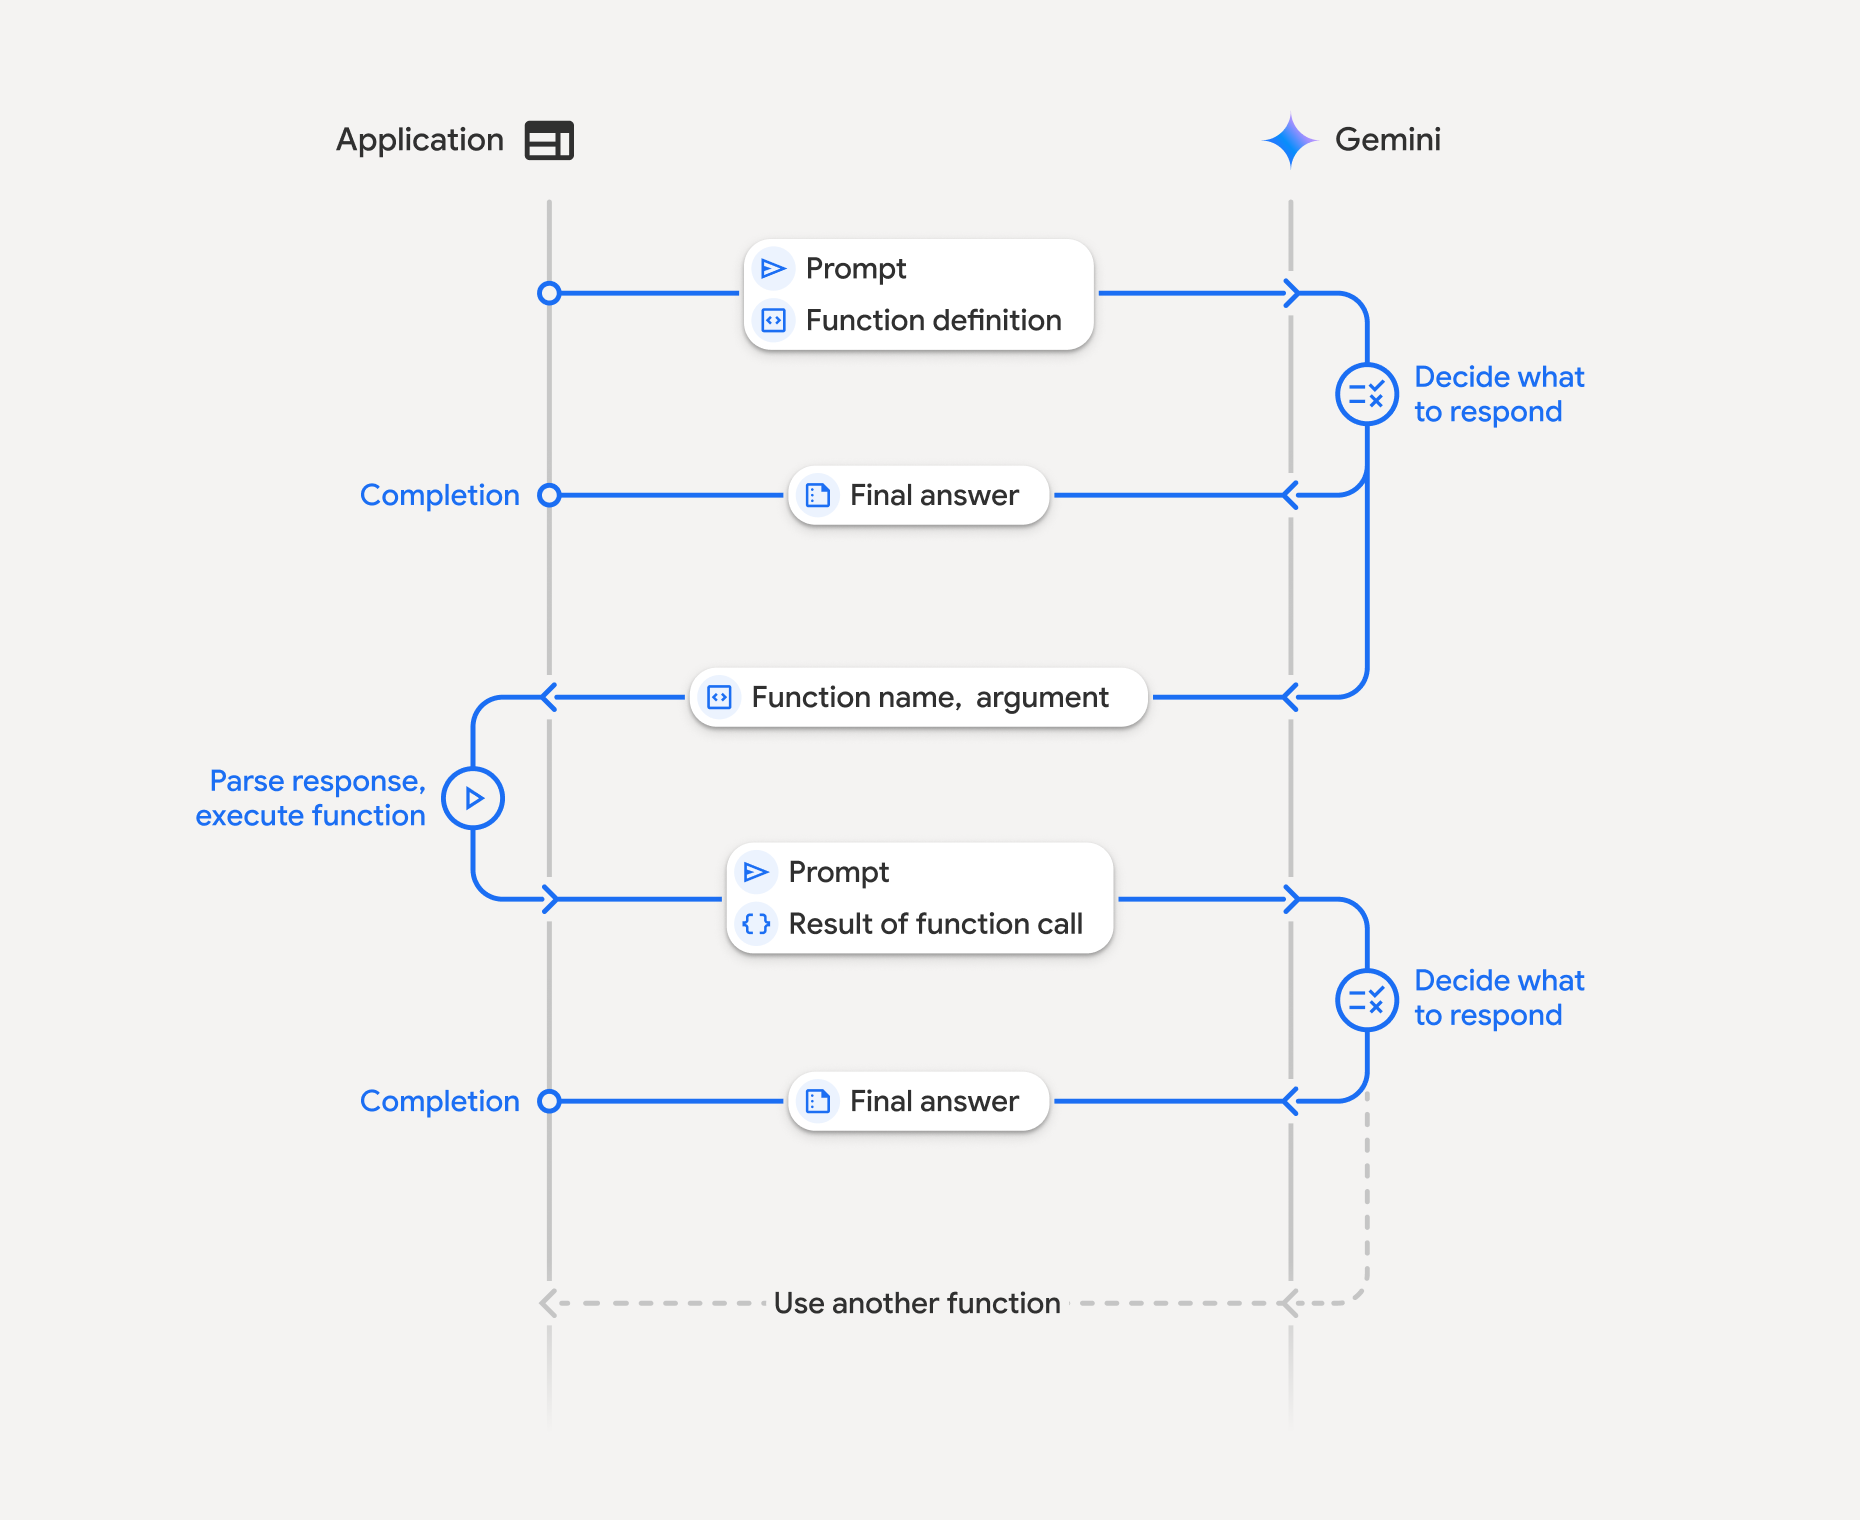

In [43]:
from langchain_ollama import ChatOllama
from langchain_community.tools import DuckDuckGoSearchRun # web_search

In [44]:
def retrieve_docs(query:str) -> str:
  """
  retrieve relevant document from the knowledge base. use retrieve_docs function to get the results

  Args:
      query: user prompt to retrieve the context
  """
  response = retriever.invoke(query)
  context = [docs.page_content for docs in response]

  return "\n".join(context) # string

In [45]:
print(retrieve_docs(query))

The digital remittance market is projected to reach USD 83.2–103.26 billion by 2034, growing at a robust 
compound annual growth rate of 13.5 to 16.3 percent (Precedence Research, 2025). Digital platforms 
have reduced their costs to 5 percent, compared to the average 7 percent of traditional channels, with 
further decreases anticipated as technologies like blockchain and stablecoins evolve. These cost savings 
are critical for low- and middle-income countries (LMICs), where remittances are a vital source of 
household income (World Bank’s Remittance Price Worldwide). As the industry advances, digital 
remittance services will become essential in achieving the United Nations Sustainable Development 
Goals (SDGs), supporting economic empowerment, poverty reduction, and equitable access to and use 
of the global financial system.
Transformative Innovations in Remittance Services
Artificial Intelligence (AI): AI is making remittances more efficient and secure by enhancing fraud 
detectio

In [46]:
def web_search(query:str) -> str:
    """
    search results from the Google web browswer to the user query
    Args:
       query: user prompt
    """
    browse = DuckDuckGoSearchRun()
    context = browse.invoke(query)
    return context

In [47]:
web_search("iran and israel")

'6 days ago -Iran and Israel have maintained no diplomatic relations since the 1979 Islamic Revolution, and their relationship has been characterized by hostility ever since. Originally, relations were relatively cordial during the first three decades of Israeli independence, and saw close partnership between ... 14 hours ago -The war followed a decades-long proxy conflict in which Iran supported an "Axis of Resistance" against Israeli and US interests in the region. Iran\'s development of nuclear enrichment capabilities has been an international controversy for decades, with Israel and its allies seeking to prevent Iranian nuclear weapons development. 19 hours ago -On 28 February 2026, Israel and the United States launched surprise airstrikes on multiple sites and cities across Iran, killing Iranian supreme leader Ali Khamenei and other Iranian officials, and starting a war. 5 days ago -Iran–Israel conflict may refer to: Iran–Israel proxy conflict · Iran–Israel conflict during the Syr

In [48]:
def extract_tool_call(text):
    import io, re
    from contextlib import redirect_stdout

    pattern = r"```tool_code\s*(.*?)\s*```"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        code = match.group(1).strip()
        f = io.StringIO()
        with redirect_stdout(f):
            result = eval(code) # interpreter
        output = f.getvalue()
        r = result if output == '' else output
        return f'```tool_output\n{str(r).strip()}\n```'''
    return None

In [49]:
llm = ChatOllama(
    model=model_name,
    temperature=0.1,
    num_predict = 1024
)

### LangGraph Implementation

- we will use the same two above tools
- retrieve_docs
- extract_tool_call

In [50]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [51]:
class AgentState(TypedDict):
    query: str
    context: str
    tool_response: str
    answer: str

In [52]:
def generate_tool_call_node(state: AgentState):
    query = state["query"]

    prompt = f'''
    You are expert router Agent, given the User Question, you need to pick relevant tools from the available Python methods only.
    At each turn, if you decide to invoke any of the function(s), it should be wrapped with ```tool_code```.
    The python methods described below are imported and available, you can only use defined methods.
    The generated code should be readable and efficient.
    The response to a method will be wrapped in ```tool_output``` use it to call more tools or generate a helpful, friendly response.
    When using a ```tool_call``` think step by step why and how it should be used.

    The following Python methods are available:

    ```python
    def retrieve_docs(query:str) -> str:
      """
      retrieve relevant document from the knowledge base. use retrieve_docs function to get the results i.e., related to finance, if not use web search
      Args:
          query: user prompt to retrieve the context
      """

    def web_search(query:str) -> str:
      """
      search results from the Google web browswer to the user query
      Args:
        query: user prompt
      """
    ```
    use the exact function tool names, don't assume the names that is not available. available function tools:
    - retrieve_docs: default or primary tool to pick if query is related to finance i.e., retrieve docs contains information on Financial Annual Survey Report related.
    - web_search: needs to be used if web search and information needs to be retrieved
    User: {query}
    '''

    tool_response = llm.invoke(prompt)
    return {"tool_response": tool_response.content}

In [53]:
def generate_final_answer_node(state: AgentState):
    query = state["query"]
    tool_response = state["tool_response"] # tool_code: what tool to pick

    context = extract_tool_call(tool_response) # context

    final_prompt = f"""
    Answer the user question from the given CONTEXT.
    <context>
    CONTEXT: {context}
    </context>
    <question>
    User Question: {query}
    </question>
    """
    results = llm.invoke(final_prompt)
    return {"answer": results.content,"context": context}

In [54]:
workflow = StateGraph(AgentState)
# Graph APIs - LangGraph
workflow.add_node("generate_tool_call", generate_tool_call_node)
workflow.add_node("generate_final_answer", generate_final_answer_node)

workflow.add_edge(START, "generate_tool_call")
workflow.add_edge("generate_tool_call", "generate_final_answer")
workflow.add_edge("generate_final_answer", END)

In [55]:
graph = workflow.compile()

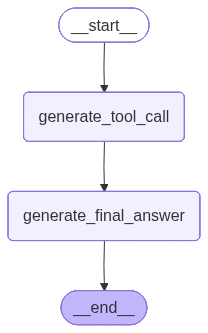

In [56]:
graph

In [57]:
query

'projected reach of the digital remittance market by 2034'

In [58]:
query = "What is linkedlist"

In [59]:
result = graph.invoke({"query": query})

In [65]:
print(result["answer"])

A LinkedList is a doubly-linked list implementation of the List and Deque interfaces. It stores elements as nodes, where each node contains data and references to the previous and next nodes. Unlike arrays, the elements in a linked list are not necessarily stored in contiguous memory locations. It's part of the Java Collections Framework and found in the `java.util` package. There are also specialized linked list structures like Skip List and Unrolled LinkedList for specific performance needs.


In [61]:
print(result['tool_response'])

The user is asking for information about "linkedlist". This is not a finance-related query, so I should use web search to find information about it.

```tool_code
print(web_search(query='what is linkedlist'))
```



In [62]:
print(result['context'])

```tool_output
LinkedListisa doubly-linked list implementation of the List and Deque interfaces. It implements all optional list operations and permits all elements (including null). 2. Features Master Java'sLinkedListin Java SE 8. Learn internals, APIs, Big-O performance, iteration, Deque/Queue usage, real-world patterns, Java 8 streams, and pitfalls with practical code examples. LinkedListisa part of the Java Collections Framework and is present in the java.util package. It implements a doublylinkedlistwhere elements are stored as nodes containing data and references to the previous and next nodes, rather than in contiguous memory locations. Alinkedlistisa type of linear data structure individual items are not necessarily at contiguous locations. The individual items are called nodes and connected with each other using links. LinkedListVariants Beyond the basic types, there are specializedlinkedliststructures for specific performance needs. Skip List: Like alinkedlistbut with multipl

In [63]:
result1 = graph.invoke({"query": "who is Messi"})

In [ ]:
result1['tool_response']

"I need to find information about Messi. Since this is a general knowledge question and not specifically finance-related, I should use web search.\n```tool_code\nprint(web_search(query='who is messi'))\n```"

In [ ]:
result1['final_response']

"Lionel Messi is an Argentinian professional footballer who plays as a forward for Inter Miami and the Argentina national team. He is widely regarded as one of the greatest soccer players of all time. He has won numerous individual accolades, including eight Ballon d'Or awards, and has won the 2022 FIFA World Cup and an Olympic gold medal in 2008."

In [ ]:
result1['context']

"```tool_output\n4 hours ago -Among his contemporary peers, Messi is most often compared and contrasted with Cristiano Ronaldo, who many consider his career rival. Both achieved numerous individual accolades, won dozens of trophies for both club and country, and are the two leading goal scorers in history. 2 days ago -Lionel Messi is anArgentine professional footballerwho plays as a forward for and captains both the Major League Soccer club Inter Miami and the Argentina national team. His individual achievements include eight Ballon d'Or awards, the most for any footballer. 3 days ago -Lionel Andrés Messi (Spanish pronunciation: [ljoˈnel anˈdɾes ˈmesi] ; born 24 June 1987), also known as Leo Messi, is anArgentine professional footballer. As of summer 2023, he plays for the Argentina national team and American club Inter Miami. At club level, he is best known for playing ... May 9, 2025 -Lionel Messi isa football player from Argentina who plays for Inter Miami. He has won the Ballon D'O

# Alternative way

In [ ]:
llm = ChatOllama(
    model="gemma3:12b",
    base_url="https://ollama.com",
    client_kwargs={
        "headers": {"Authorization": "Bearer " + os.environ.get("OLLAMA_API_KEY")}
    }
)

response = llm.invoke("Top 10 beautiful cities in Asia")
print(response.content)

Okay, compiling a list of the "most beautiful" cities is inherently subjective, as beauty lies in the eye of the beholder! However, based on a combination of architecture, natural setting, cultural richness, and overall aesthetic appeal, here's a list of 10 incredibly beautiful cities in Asia, with some notes on what makes them special.  I'll try to offer a mix of well-known and slightly less-obvious choices.  **Please read the notes at the very end for important caveats about ranking.**

**1. Kyoto, Japan:**

*   **Why it's beautiful:** Kyoto is the epitome of traditional Japan.  It's filled with stunning temples (Kinkaku-ji - Golden Pavilion, Fushimi Inari-taisha with its thousands of red torii gates, Kiyomizu-dera), serene gardens, historic wooden machiya houses, and geisha districts. The surrounding hills provide a gorgeous backdrop. The changing seasons bring spectacular colors (cherry blossoms in spring, vibrant foliage in autumn).
*   **Key Visuals:** Temples, traditional archit

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal

In [ ]:
class Route(BaseModel):
    step: Literal["retrieve_docs", "web_search"] = Field(None, description="Which is the right tool for the given user query")

router = llm.with_structured_output(Route)

In [ ]:
def web_search(state: AgentState):
    """
    search results from the Google web browswer to the user query
    """
    browse = DuckDuckGoSearchRun()
    context = browse.invoke(state["query"])
    return {"context":context}

In [ ]:
def retrieve_docs(state: AgentState):
  """
  retrieve relevant document from the knowledge base. use retrieve_docs function to get the results
  """
  response = retriever.invoke(state["query"])
  context = [docs.page_content for docs in response]

  return {"context":"\n".join(context)}

In [ ]:
# Conditional edge node
def route_decision(state: AgentState):
    if state["tool_response"] == "retrieve_docs":
        return "retrieve_docs"
    elif state["tool_response"] == "web_search":
        return "web_search"

In [ ]:
def llm_call_router(state: AgentState):
    """Route the input to the appropriate node"""

    SYSTEM_PROMPT = """
    Route the input to retrieve_docs or web_search based on the user's request.
    use the exact function tool names to route and don't assume the names that is not available.

    available function tools:
    - retrieve_docs: default or primary tool to pick if query is related to finance i.e., retrieve docs contains information on Financial Annual Survey Report related.
    - web_search: needs to be used if web search and information needs to be retrieved

    Strictly return in JSON as per the format i.e., {"step": "retrieve_docs" or "web_search"}
    """

    decision = router.invoke(
        [{"role": "system", "content": SYSTEM_PROMPT},
         {"role": "user", "content": state["query"]}]
    )

    return {"tool_response": decision.step}

In [ ]:
def answer_generation(state: AgentState) -> AgentState:
    question = state["query"]
    tool_used = state["tool_response"]
    context = state["context"]


    SYSTEM_PROMPT = """
    You are an expert financial analyst specializing in corporate finance.
    - For retrieve_docs queries: default or primary tool to pick if query is related to finance i.e., retrieve docs contains information on Financial Annual Survey Report related.
    - For web_search queries: needs to be used if web search and information needs to be retrieved
    """
    user_msg_template = {
            "retrieve_docs": f"Question: {question}\n\nDocuments:\n{context}\n\n If question is not from the CONTEXT, if not say not enough information. Keep concise response",
            "web_search": f"Question: {question}\n\n{context}. Keep concise response"
    }
    HUMAN_PROMPT = user_msg_template.get(tool_used, user_msg_template["retrieve_docs"])

    prompt = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": HUMAN_PROMPT}
    ]
    response = llm.invoke(prompt)


    return {"final_response":response.content}

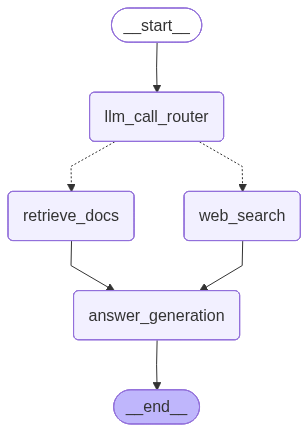

In [ ]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("llm_call_router", llm_call_router)
graph_builder.add_node("retrieve_docs", retrieve_docs)
graph_builder.add_node("web_search", web_search)
graph_builder.add_node("answer_generation", answer_generation)


graph_builder.add_edge(START, "llm_call_router")
graph_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {"retrieve_docs": "retrieve_docs","web_search": "web_search"}
)
graph_builder.add_edge("retrieve_docs", "answer_generation")
graph_builder.add_edge("web_search", "answer_generation")
graph_builder.add_edge("answer_generation",END)
graph = graph_builder.compile()
graph

In [ ]:
query

'projected reach of the digital remittance market by 2034'

In [1]:
result = graph.invoke({"query":query})

NameError: name 'graph' is not defined

In [ ]:
print(result['final_response'])

The projected reach of the digital remittance market by 2034 varies across different reports:

*   **$103.26 billion** (with a 15.1% CAGR from 2025-2034)
*   **$51.57 billion** (with a 4.00% CAGR from 2025-2034)
*   **$4178.15 billion** (with an 11.62% CAGR from 2025-2034)
*   **$16.8 billion** (up from $5.5 billion in 2025)



These differing projections likely reflect varying methodologies, scopes (e.g., global vs. regional), and definitions of "digital remittance."


In [ ]:
print(result['tool_response'])

web_search
